##### Predict Missing Revenue Using Other Columns (Advanced)
If you have other features like company size, industry, etc., train a model to predict missing revenue values.

Why: Best for high-stakes or production-level imputation, but needs effort and additional features.

#### Step : 1
## Data Cleaning

Data Source : https://www.kaggle.com/datasets/rashikrahmanpritom/data-science-job-posting-on-glassdoor?select=Uncleaned_DS_jobs.csv

    - import required library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("Data/Uncleaned_DS_jobs.csv")
data

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1
668,668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,-1.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1
669,669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,-1.0,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1
670,670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1


In [4]:
# first 5 rows of the dataset
data.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [5]:
# last 5 rows of the dataset
data.tail()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
667,667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1
668,668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,-1.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1
669,669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,-1.0,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1
670,670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1
671,671,Data Scientist,$105K-$167K (Glassdoor est.),Description\n\nThe Data Scientist will be part...,2.7,1-800-Flowers\n2.7,"New York, NY","Carle Place, NY",1001 to 5000 employees,1976,Company - Public,Wholesale,Business Services,$1 to $2 billion (USD),-1


In [6]:
# Check the info of the datsets
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    object 
 2   Salary Estimate    672 non-null    object 
 3   Job Description    672 non-null    object 
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    object 
 6   Location           672 non-null    object 
 7   Headquarters       672 non-null    object 
 8   Size               672 non-null    object 
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    object 
 11  Industry           672 non-null    object 
 12  Sector             672 non-null    object 
 13  Revenue            672 non-null    object 
 14  Competitors        672 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 78.9+ KB


In [7]:
#Check the Number of Rows and Columns in the dataset
data.shape

(672, 15)

In [8]:
print("Number of Rows: ",data.shape[0])
print("Number of Columns: ",data.shape[1])

Number of Rows:  672
Number of Columns:  15


In [9]:
# Check the datatypes of all columns
data.dtypes

index                  int64
Job Title             object
Salary Estimate       object
Job Description       object
Rating               float64
Company Name          object
Location              object
Headquarters          object
Size                  object
Founded                int64
Type of ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
dtype: object

In [10]:
# Check the duplicate values in the  dataset
data.duplicated().sum()

0

In [11]:
# Check the Null Values in the dataset
data.isnull().sum()

index                0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64

### Column Sepration in Numerical and Categorical Columns 

In [12]:
data.columns

Index(['index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

In [13]:
data_num = data.select_dtypes('number')
data_num

,index,Rating,Founded
0,0,3.1,1993
1,1,4.2,1968
2,2,3.8,1981
3,3,3.5,2000
4,4,2.9,1998
...,...,...,...
667,667,3.6,1989
668,668,-1.0,-1
669,669,-1.0,-1
670,670,5.0,-1


In [14]:
data_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    672 non-null    int64  
 1   Rating   672 non-null    float64
 2   Founded  672 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 15.9 KB


In [15]:
data_cat = data.select_dtypes("object")
data_cat

,Job Title,Salary Estimate,Job Description,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,Competitors
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1
668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1
669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1
670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1


In [16]:
# Remove Extra Text and Symbols 
# Remove text like "(Glassdoor est.)"  and Symbols Like ", "$", "K"
data['Cleaned_Sal'] = data['Salary Estimate'].str.replace(r'\$|K|\s|\(Glassdoor est.\)', '', regex=True)
data

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Cleaned_Sal
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",137-171
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,137-171
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,137-171
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",137-171
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",137-171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1,105-167
668,668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,-1.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1,105-167
669,669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,-1.0,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1,105-167
670,670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1,105-167


In [17]:
# Keep only rows with a valid '-' delimiter

data = data[data['Cleaned_Sal'].str.contains('-', na=False)]
data

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Cleaned_Sal
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",137-171
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,137-171
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,137-171
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",137-171
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",137-171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1,105-167
668,668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,-1.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1,105-167
669,669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,-1.0,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1,105-167
670,670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1,105-167


In [18]:
# Step 3: Split into Min and Max and convert to int
data[['Min', 'Max']] = data['Cleaned_Sal'].str.split('-', expand=True)
data['Min'] = pd.to_numeric(data['Min'], errors='coerce')
data['Max'] = pd.to_numeric(data['Max'], errors='coerce')

In [19]:
# Calculate average
data['Avg Salary'] = (data['Min'] + data['Max']) / 2

In [20]:
# data['Avg Salary($)'] = data['Avg Salary($)']*1000
# data

In [21]:
data.drop(['Cleaned_Sal','Min','Max'], axis=1, inplace=True)
data

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1,136.0
668,668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,-1.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
669,669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,-1.0,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
670,670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1,136.0


In [22]:
data.drop(['index'], axis=1, inplace=True)
data

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1,136.0
668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,-1.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,-1.0,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1,136.0


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          672 non-null    object 
 1   Salary Estimate    672 non-null    object 
 2   Job Description    672 non-null    object 
 3   Rating             672 non-null    float64
 4   Company Name       672 non-null    object 
 5   Location           672 non-null    object 
 6   Headquarters       672 non-null    object 
 7   Size               672 non-null    object 
 8   Founded            672 non-null    int64  
 9   Type of ownership  672 non-null    object 
 10  Industry           672 non-null    object 
 11  Sector             672 non-null    object 
 12  Revenue            672 non-null    object 
 13  Competitors        672 non-null    object 
 14  Avg Salary         652 non-null    float64
dtypes: float64(2), int64(1), object(12)
memory usage: 78.9+ KB


In [24]:
data_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Job Title          672 non-null    object
 1   Salary Estimate    672 non-null    object
 2   Job Description    672 non-null    object
 3   Company Name       672 non-null    object
 4   Location           672 non-null    object
 5   Headquarters       672 non-null    object
 6   Size               672 non-null    object
 7   Type of ownership  672 non-null    object
 8   Industry           672 non-null    object
 9   Sector             672 non-null    object
 10  Revenue            672 non-null    object
 11  Competitors        672 non-null    object
dtypes: object(12)
memory usage: 63.1+ KB


In [25]:
data_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    672 non-null    int64  
 1   Rating   672 non-null    float64
 2   Founded  672 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 15.9 KB


## Summary

    - This Dataset has a `672 Rows` and `15 Columns` .

#### Numer Of Numerical Columns : 3
    - Founded       : Year of Founded the Company
    - Rating        : Rating of that post
    - Avg Salary($) : Average Salary as Job Desceription and Title

#### Number of Categorical Columns : 11

    - Job Title        : Title of the job posting
    - Job Description  : This contains the full description of that job
    - Company Name     : Name of company
    - Location         : Location of the company
    - Headquarters     : Location of the headquater
    - Size             : Total employee in that company
    - Type of ownership: Describes the company type i.e non-profit/public/private farm etc
    - Industry         : Field applicant will work in
    - Sector           : Field applicant will work in
    - Revenue          : Total revenue of the company
    - Competitors      : Name Of the Competitors

    - This  Glassdoor job dataset consists of 672 entries with detailed information on job postings,
including company attributes, salaries, and job     descriptions.
It features 3 numerical columns like average salary, rating, and company founding year, 
along with 11 categorical columns describing company characteristics and job metadata.
This dataset is valuable for analyzing job market trends, salary patterns, and employer profiles across different sectors.

In [26]:
data.head(3)

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0


In [27]:
data['Location'].value_counts()

Location
San Francisco, CA    69
New York, NY         50
Washington, DC       26
Boston, MA           24
Chicago, IL          22
                     ..
Oshkosh, WI           1
Culver City, CA       1
Lake Oswego, OR       1
New Orleans, LA       1
Irwindale, CA         1
Name: count, Length: 207, dtype: int64

In [28]:
data.drop(['Salary Estimate'],axis=1,inplace=True)

In [29]:
data.head(3)

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0


In [30]:
data.select_dtypes('number').head(3)

,Rating,Founded,Avg Salary
0,3.1,1993,154.0
1,4.2,1968,154.0
2,3.8,1981,154.0


In [31]:
data.select_dtypes('object').head(4)

,Job Title,Job Description,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,Competitors
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."


### Cleaning Job Description

In [32]:
# for i in data['Job Description'].values:
#     print(i)

### Cleaning Company Name Column

In [33]:
data['Company Name']

0               Healthfirst\n3.1
1                   ManTech\n4.2
2            Analysis Group\n3.8
3                   INFICON\n3.5
4        Affinity Solutions\n2.9
                 ...            
667                TRANZACT\n3.6
668                         JKGT
669                   AccessHope
670    ChaTeck Incorporated\n5.0
671           1-800-Flowers\n2.7
Name: Company Name, Length: 672, dtype: object

In [34]:
data['Company Name'].str.split("\n")[0][0]

'Healthfirst'

In [35]:
def Company_name_clean(text):
    text = text.split('\n')[0]
    return text

In [36]:
data['Company Name'] = data['Company Name'].apply(Company_name_clean)

In [37]:
data

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1,136.0
668,Data Scientist,Job Description\nBecome a thought leader withi...,-1.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
669,Data Scientist,Join a thriving company that is changing the w...,-1.0,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
670,Data Scientist,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1,136.0


In [38]:
data[data['Rating'] == -1]

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
154,ELISA RESEARCH SCIENTIST (CV-15),"Covaxx, a subsidiary of the UBI Group, has joi...",-1.0,Covid-19 Search Partners,"Hauppauge, NY",-1,-1,-1,-1,-1,-1,-1,-1,99.5
158,Machine Learning Engineer,Overview\n\nRadical Convergence is a fast-pace...,-1.0,Radical Convergence,"Reston, VA",-1,-1,-1,-1,-1,-1,-1,-1,133.0
230,Data Scientist,Senior Data Scientist Active Secret clearance ...,-1.0,"Encode, Inc.","Norfolk, VA","Manalapan, NJ",1 to 50 employees,-1,Company - Private,IT Services,Information Technology,$5 to $10 million (USD),-1,97.0
282,Data Scientist,Greetings from Trovetechs!!!\n\nÂ\n\nWe have a...,-1.0,Trovetechs Inc,"San Francisco, CA","Hillsborough, NJ",Unknown,-1,Company - Private,-1,-1,Unknown / Non-Applicable,-1,120.5
285,Data Scientist,Greetings from Trovetechs!!!\n\nÂ\n\nWe have a...,-1.0,Trovetechs Inc,"San Francisco, CA","Hillsborough, NJ",Unknown,-1,Company - Private,-1,-1,Unknown / Non-Applicable,-1,183.0
290,Data Scientist,Work Authorization Those authorized to work in...,-1.0,PETADATA,"San Francisco, CA","Fremont, CA",51 to 200 employees,-1,Company - Private,-1,-1,Unknown / Non-Applicable,-1,183.0
319,Data Scientist,"Job Description\nSelecting features, building ...",-1.0,Microagility,"New York, NY","Princeton, NJ",1 to 50 employees,-1,Company - Private,Consulting,Business Services,$1 to $5 million (USD),-1,NaN
322,Data Scientist,Job Description\nData Scientist\nAre you inter...,-1.0,"Rainmaker Resources, LLC","Cincinnati, OH","Cincinnati, OH",1 to 50 employees,-1,Company - Private,-1,-1,Unknown / Non-Applicable,-1,NaN
329,Data Scientist,Description:\n\nPosition Requires a Top Secret...,-1.0,B4Corp,"Reston, VA","Leesburg, VA",51 to 200 employees,-1,Company - Private,IT Services,Information Technology,Unknown / Non-Applicable,-1,113.0
338,Data Scientist,Work in a fast growing startup with unlimited ...,-1.0,Stride Search,"San Francisco, CA","Westlake Village, CA",1 to 50 employees,-1,Company - Private,-1,-1,Less than $1 million (USD),-1,113.0


In [39]:
data.describe()

,Rating,Founded,Avg Salary
count,672.000000,672.000000,652.000000
mean,3.518601,1635.529762,121.782209
std,1.410329,756.746640,38.672997
min,-1.000000,-1.000000,43.500000
25%,3.300000,1917.750000,103.000000
50%,3.800000,1995.000000,114.000000
75%,4.300000,2009.000000,136.000000
max,5.000000,2019.000000,271.500000


In [40]:
new_df = data.copy()
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1,136.0
668,Data Scientist,Job Description\nBecome a thought leader withi...,-1.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
669,Data Scientist,Join a thriving company that is changing the w...,-1.0,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
670,Data Scientist,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1,136.0


In [41]:
new_df['Rating'] = new_df['Rating'].replace(-1,new_df['Rating'].median())

In [42]:
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1,136.0
668,Data Scientist,Job Description\nBecome a thought leader withi...,3.8,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
669,Data Scientist,Join a thriving company that is changing the w...,3.8,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
670,Data Scientist,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1,136.0


In [43]:
new_df.describe()

,Rating,Founded,Avg Salary
count,672.000000,672.000000,652.000000
mean,3.875744,1635.529762,121.782209
std,0.588001,756.746640,38.672997
min,2.000000,-1.000000,43.500000
25%,3.500000,1917.750000,103.000000
50%,3.800000,1995.000000,114.000000
75%,4.300000,2009.000000,136.000000
max,5.000000,2019.000000,271.500000


In [44]:
new_df['Size']

0       1001 to 5000 employees
1      5001 to 10000 employees
2       1001 to 5000 employees
3        501 to 1000 employees
4          51 to 200 employees
                ...           
667     1001 to 5000 employees
668                         -1
669                         -1
670          1 to 50 employees
671     1001 to 5000 employees
Name: Size, Length: 672, dtype: object

In [45]:
import re
str1 = "1001 to 5000 employees"
numbers = re.findall(r'\d+', str1) 
numbers

['1001', '5000']

In [46]:
Avg_emp = (int(numbers[0]) + int(numbers[1]))/2
Avg_emp

3000.5

In [47]:
def size_clean(text):
    numbers = re.findall(r'\d+', text)
    if len(numbers) == 2:
        Avg_emp = (int(numbers[0]) + int(numbers[1]))//2
    else:
        return -1
    return Avg_emp

In [48]:
new_df['Size'].apply(size_clean)

0      3000
1      7500
2      3000
3       750
4       125
       ... 
667    3000
668      -1
669      -1
670      25
671    3000
Name: Size, Length: 672, dtype: int64

In [49]:
new_df['Size'] = new_df['Size'].apply(size_clean)

In [50]:
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",3000,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,-1,136.0
668,Data Scientist,Job Description\nBecome a thought leader withi...,3.8,JKGT,"San Francisco, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
669,Data Scientist,Join a thriving company that is changing the w...,3.8,AccessHope,"Irwindale, CA",-1,-1,-1,-1,-1,-1,-1,-1,136.0
670,Data Scientist,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",25,-1,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),-1,136.0


In [51]:
new_df.describe()

,Rating,Size,Founded,Avg Salary
count,672.000000,672.000000,672.000000,652.000000
mean,3.875744,1303.424107,1635.529762,121.782209
std,0.588001,2211.428037,756.746640,38.672997
min,2.000000,-1.000000,-1.000000,43.500000
25%,3.500000,25.000000,1917.750000,103.000000
50%,3.800000,125.000000,1995.000000,114.000000
75%,4.300000,750.000000,2009.000000,136.000000
max,5.000000,7500.000000,2019.000000,271.500000


In [52]:
new_df['Size'] = new_df['Size'].replace(-1,125)

In [53]:
new_df.head()

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154.0
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,154.0
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,154.0
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",154.0


In [54]:
new_df.describe()

,Rating,Size,Founded,Avg Salary
count,672.000000,672.000000,672.000000,652.000000
mean,3.875744,1326.674107,1635.529762,121.782209
std,0.588001,2198.194792,756.746640,38.672997
min,2.000000,25.000000,-1.000000,43.500000
25%,3.500000,125.000000,1917.750000,103.000000
50%,3.800000,125.000000,1995.000000,114.000000
75%,4.300000,750.000000,2009.000000,136.000000
max,5.000000,7500.000000,2019.000000,271.500000


In [55]:
new_df['Revenue'].value_counts()

Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64

In [56]:
# Replace "Unknown" and "-1" with NaN
new_df['Revenue'] = new_df['Revenue'].replace(
    ['Unknown / Non-Applicable', '-1'],
    np.nan
)

In [57]:
# new_df

In [58]:
lambda x : "Yes" if "," in x else "No"

<function __main__.<lambda>(x)>

In [59]:
new_df['Revenue'].apply(lambda x: "Yes" if isinstance(x, str) and "Less than" in x else "No").value_counts()

Revenue
No     658
Yes     14
Name: count, dtype: int64

In [60]:
new_df['Revenue'].value_counts()

Revenue
$100 to $500 million (USD)          94
$10+ billion (USD)                  63
$2 to $5 billion (USD)              45
$10 to $25 million (USD)            41
$1 to $2 billion (USD)              36
$25 to $50 million (USD)            36
$50 to $100 million (USD)           31
$1 to $5 million (USD)              31
$500 million to $1 billion (USD)    19
$5 to $10 million (USD)             14
Less than $1 million (USD)          14
$5 to $10 billion (USD)              8
Name: count, dtype: int64

### Clean Revenue

In [61]:
new_df['Revenue'].isnull().sum()

240

In [62]:
new_df['Revenue'].value_counts()

Revenue
$100 to $500 million (USD)          94
$10+ billion (USD)                  63
$2 to $5 billion (USD)              45
$10 to $25 million (USD)            41
$1 to $2 billion (USD)              36
$25 to $50 million (USD)            36
$50 to $100 million (USD)           31
$1 to $5 million (USD)              31
$500 million to $1 billion (USD)    19
$5 to $10 million (USD)             14
Less than $1 million (USD)          14
$5 to $10 billion (USD)              8
Name: count, dtype: int64

In [63]:
def parse_revenue(text):
    if not pd.isna(text):
        text = text.replace('(USD)','')
        text = text.replace('$','')
    else:
        return np.nan
    return text

In [64]:
new_df['Revenue']

0                             NaN
1          $1 to $2 billion (USD)
2      $100 to $500 million (USD)
3      $100 to $500 million (USD)
4                             NaN
                  ...            
667                           NaN
668                           NaN
669                           NaN
670        $1 to $5 million (USD)
671        $1 to $2 billion (USD)
Name: Revenue, Length: 672, dtype: object

In [65]:
new_df['Revenue'] = new_df['Revenue'].apply(parse_revenue)

In [66]:
import pandas as pd
import numpy as np
import re

# Step 1: Clean revenue string
def clean_revenue(revenue_str):
    if pd.isna(revenue_str):
        return np.nan

    revenue_str = revenue_str.lower()

    if "less than" in revenue_str:
        return "0 - 1M"
    if "1 to 5 million" in revenue_str:
        return "1M - 5M"
    if "5 to 10 million" in revenue_str:
        return "5M - 10M"
    if "10 to 25 million" in revenue_str:
        return "10M - 25M"
    if "25 to 50 million" in revenue_str:
        return "25M - 50M"
    if "50 to 100 million" in revenue_str:
        return "50M - 100M"
    if "100 to 500 million" in revenue_str:
        return "100M - 500M"
    if "500 million to 1 billion" in revenue_str:
        return "500M - 1B"
    if "1 to 2 billion" in revenue_str:
        return "1B - 2B"
    if "2 to 5 billion" in revenue_str:
        return "2B - 5B"
    if "5 to 10 billion" in revenue_str:
        return "5B - 10B"
    if "10+ billion" in revenue_str:
        return "10B+"
    if "-1" in revenue_str:
        return np.nan
    
    return revenue_str

In [67]:
new_df['Revenue_clean'] = new_df['Revenue'].apply(clean_revenue)

In [68]:
# Step 2: Convert cleaned revenue to min/max/avg
def parse_revenue_range(revenue_str):
    if pd.isna(revenue_str):
        return pd.Series([np.nan, np.nan, np.nan])

    # Remove unwanted symbols
    revenue_str = revenue_str.replace('$', '').replace(',', '').replace('usd', '').strip()
    revenue_str = revenue_str.replace('B', 'e9').replace('M', 'e6').replace('+', '')

    if " - " in revenue_str:
        min_val, max_val = revenue_str.split(" - ")
        min_val = float(eval(min_val.strip()))
        max_val = float(eval(max_val.strip()))
        avg_val = (min_val + max_val) / 2
        return pd.Series([min_val, max_val, avg_val])
    
    elif 'e' in revenue_str:  # like "10e9"
        val = float(eval(revenue_str))
        return pd.Series([val, val, val])

    return pd.Series([np.nan, np.nan, np.nan])

In [69]:
new_df['Revenue_clean']

0              NaN
1          1B - 2B
2      100M - 500M
3      100M - 500M
4              NaN
          ...     
667            NaN
668            NaN
669            NaN
670        1M - 5M
671        1B - 2B
Name: Revenue_clean, Length: 672, dtype: object

In [70]:
new_df[["Revenue Min", "Revenue Max", "Revenue Avg"]] = new_df["Revenue_clean"].apply(parse_revenue_range)

In [71]:
new_df['Revenue'].value_counts()

Revenue
100 to 500 million           94
10+ billion                  63
2 to 5 billion               45
10 to 25 million             41
1 to 2 billion               36
25 to 50 million             36
50 to 100 million            31
1 to 5 million               31
500 million to 1 billion     19
5 to 10 million              14
Less than 1 million          14
5 to 10 billion               8
Name: count, dtype: int64

In [72]:
new_df.head()

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary,Revenue_clean,Revenue Min,Revenue Max,Revenue Avg
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,NaN,"EmblemHealth, UnitedHealth Group, Aetna",154.0,NaN,NaN,NaN,NaN
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,1 to 2 billion,-1,154.0,1B - 2B,1.000000e+09,2.000000e+09,1.500000e+09
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,100 to 500 million,-1,154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,100 to 500 million,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",154.0,NaN,NaN,NaN,NaN


In [73]:
new_df['Revenue'].isna().sum()

240

In [74]:
new_df['Revenue'].mode()

0    100 to 500 million 
Name: Revenue, dtype: object

##### Keep the missing values

### 

In [75]:
new_df['Competitors'].value_counts()

Competitors
-1                                                                501
Roche, GlaxoSmithKline, Novartis                                   10
Los Alamos National Laboratory, Battelle, SRI International         6
Leidos, CACI International, Booz Allen Hamilton                     6
MIT Lincoln Laboratory, Lockheed Martin, Northrop Grumman           3
                                                                 ... 
Pfizer, GlaxoSmithKline                                             1
Square, Amazon, Apple                                               1
Lumentum Operations, Keysight Technologies, O-Net Technologies      1
Munich Re, Hannover RE, SCOR                                        1
Genomic Health, Myriad Genetics, The Broad Institute                1
Name: count, Length: 108, dtype: int64

In [76]:
new_df.loc[:,['Industry','Competitors']]

,Industry,Competitors
0,Insurance Carriers,"EmblemHealth, UnitedHealth Group, Aetna"
1,Research & Development,-1
2,Consulting,-1
3,Electrical & Electronic Manufacturing,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Advertising & Marketing,"Commerce Signals, Cardlytics, Yodlee"
...,...,...
667,Advertising & Marketing,-1
668,-1,-1
669,-1,-1
670,Advertising & Marketing,-1


In [77]:
# Step 1: Replace -1 with np.nan for clarity
new_df['Competitors'] = new_df['Competitors'].replace('-1', np.nan)

In [78]:
def fill_competitors(row):
    if pd.isna(row['Competitors']):
        industry = row['Industry']
    
        most_common = new_df[new_df['Industry'] == industry]['Competitors'].mode()
        if not most_common.empty:
            return most_common[0]
        else:
            return "Unknown"  # Fallback if no competitors available in that industry
    else:
        return row['Competitors']

In [79]:
new_df['Competitors'] = new_df.apply(fill_competitors,axis=1)

In [80]:
new_df[new_df['Industry'] == new_df['Industry']][['Industry','Competitors']]

,Industry,Competitors
0,Insurance Carriers,"EmblemHealth, UnitedHealth Group, Aetna"
1,Research & Development,"Los Alamos National Laboratory, Battelle, SRI ..."
2,Consulting,"Booz Allen Hamilton, SAIC, LMI"
3,Electrical & Electronic Manufacturing,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Advertising & Marketing,"Commerce Signals, Cardlytics, Yodlee"
...,...,...
667,Advertising & Marketing,"Commerce Signals, Cardlytics, Yodlee"
668,-1,"AT&T, Verizon"
669,-1,"AT&T, Verizon"
670,Advertising & Marketing,"Commerce Signals, Cardlytics, Yodlee"


In [81]:
new_df[new_df['Industry'] == 'Advertising & Marketing']['Competitors'].mode()

0    Commerce Signals, Cardlytics, Yodlee
Name: Competitors, dtype: object

In [82]:
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary,Revenue_clean,Revenue Min,Revenue Max,Revenue Avg
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,NaN,"EmblemHealth, UnitedHealth Group, Aetna",154.0,NaN,NaN,NaN,NaN
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,1 to 2 billion,"Los Alamos National Laboratory, Battelle, SRI ...",154.0,1B - 2B,1.000000e+09,2.000000e+09,1.500000e+09
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,100 to 500 million,"Booz Allen Hamilton, SAIC, LMI",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,100 to 500 million,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",154.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",3000,1989,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",136.0,NaN,NaN,NaN,NaN
668,Data Scientist,Job Description\nBecome a thought leader withi...,3.8,JKGT,"San Francisco, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN
669,Data Scientist,Join a thriving company that is changing the w...,3.8,AccessHope,"Irwindale, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN
670,Data Scientist,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",25,-1,Company - Private,Advertising & Marketing,Business Services,1 to 5 million,"Commerce Signals, Cardlytics, Yodlee",136.0,1M - 5M,1.000000e+06,5.000000e+06,3.000000e+06


In [83]:
# new_df.isna().sum()

In [84]:
def founded_year(value):
    if value != -1:
        year = (2025 - value)
        return year
    else:
        return -1

In [85]:
new_df['Company_year'] = new_df['Founded'].apply(founded_year)

In [86]:
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary,Revenue_clean,Revenue Min,Revenue Max,Revenue Avg,Company_year
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,NaN,"EmblemHealth, UnitedHealth Group, Aetna",154.0,NaN,NaN,NaN,NaN,32
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,1 to 2 billion,"Los Alamos National Laboratory, Battelle, SRI ...",154.0,1B - 2B,1.000000e+09,2.000000e+09,1.500000e+09,57
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,100 to 500 million,"Booz Allen Hamilton, SAIC, LMI",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,44
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,100 to 500 million,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,25
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",154.0,NaN,NaN,NaN,NaN,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",3000,1989,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",136.0,NaN,NaN,NaN,NaN,36
668,Data Scientist,Job Description\nBecome a thought leader withi...,3.8,JKGT,"San Francisco, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1
669,Data Scientist,Join a thriving company that is changing the w...,3.8,AccessHope,"Irwindale, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1
670,Data Scientist,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",25,-1,Company - Private,Advertising & Marketing,Business Services,1 to 5 million,"Commerce Signals, Cardlytics, Yodlee",136.0,1M - 5M,1.000000e+06,5.000000e+06,3.000000e+06,-1


In [87]:
new_df['Job Title'].value_counts().head(10)

Job Title
Data Scientist                                                                                      337
Data Engineer                                                                                        26
Senior Data Scientist                                                                                19
Machine Learning Engineer                                                                            16
Data Analyst                                                                                         12
Senior Data Analyst                                                                                   6
Senior Data Engineer                                                                                  5
Data Science Software Engineer                                                                        4
ENGINEER - COMPUTER SCIENTIST - RESEARCH COMPUTER SCIENTIST - SIGNAL PROCESSING - SAN ANTONIO OR      4
Data Scientist - TS/SCI FSP or CI Required            

### Create Columns on basic of languages

#### Step 1

In [88]:
new_df['Job Description'] = new_df['Job Description'].str.lower()

In [89]:
languages_to_learn = [
    "Python",               # Core language for data science, ML, data engineering
    "SQL",                  # Essential for data analysis and data engineering
    "R",                    # Useful for statistics-heavy data science roles
    "Java",                 # Important for big data tools and backend systems
    "Scala",                # Used in Spark and big data engineering
    "C++",                  # Used in performance-critical systems and ML engineering
    "MATLAB",               # Used in research and signal processing roles
    "JavaScript",           # Occasionally used for dashboarding (e.g., D3.js)
    "Shell scripting",      # Helpful for automation in data engineering
    "hadoop"
]

required_skills = []


In [90]:
def extract_skills(text):
    found_skills = []
    text_lower = text.lower()
    for skill in languages_to_learn:
        if re.search(r'\b' + re.escape(skill.lower()) + r'\b', text_lower):
            found_skills.append(skill)
    return list(set(found_skills))

new_df['RequiredSkills'] = new_df['Job Description'].apply(extract_skills)

In [91]:
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary,Revenue_clean,Revenue Min,Revenue Max,Revenue Avg,Company_year,RequiredSkills
0,Sr Data Scientist,description\n\nthe senior data scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,NaN,"EmblemHealth, UnitedHealth Group, Aetna",154.0,NaN,NaN,NaN,NaN,32,[]
1,Data Scientist,"secure our nation, ignite your future\n\njoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,1 to 2 billion,"Los Alamos National Laboratory, Battelle, SRI ...",154.0,1B - 2B,1.000000e+09,2.000000e+09,1.500000e+09,57,"[hadoop, SQL]"
2,Data Scientist,overview\n\n\nanalysis group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,100 to 500 million,"Booz Allen Hamilton, SAIC, LMI",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,44,"[R, Python]"
3,Data Scientist,job description:\n\ndo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,100 to 500 million,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,25,"[MATLAB, SQL, Python]"
4,Data Scientist,data scientist\naffinity solutions / marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",154.0,NaN,NaN,NaN,NaN,27,"[R, SQL, Python]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,summary\n\nwe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",3000,1989,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",136.0,NaN,NaN,NaN,NaN,36,"[hadoop, SQL, Python]"
668,Data Scientist,job description\nbecome a thought leader withi...,3.8,JKGT,"San Francisco, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1,[]
669,Data Scientist,join a thriving company that is changing the w...,3.8,AccessHope,"Irwindale, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1,"[Java, hadoop, SQL, Python, R, Scala]"
670,Data Scientist,100 remote opportunity as an ainlp data scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",25,-1,Company - Private,Advertising & Marketing,Business Services,1 to 5 million,"Commerce Signals, Cardlytics, Yodlee",136.0,1M - 5M,1.000000e+06,5.000000e+06,3.000000e+06,-1,"[Java, hadoop, Python, R, Scala]"


In [92]:
# new_df['Job Title'].values

In [93]:
# for i in new_df['Job Title'].values:
#     if  ("Sr" in i) or ('Senior' in i):
#         print(i)

In [94]:
# new_df['Job Title'].values

In [95]:
# for i in new_df['Job Title'].values:
#     if  ("Jr" in i) or ('Principal' in i):
#         print(i)

In [96]:
def get_experience_level(title):
    if  ("sr" in title.lower()) or ('senior' in title.lower()) or ('lead' in title.lower()) or ('principal' in title.lower()):
        return "Senior"
    elif 'jr'in title.lower():
        return "Junior"
    else:
        return "Mid-Level"
        

In [97]:
pd.set_option('display.max_columns',None)

In [98]:
new_df['Experience_Level']  = new_df['Job Title'].apply(get_experience_level)

In [99]:
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary,Revenue_clean,Revenue Min,Revenue Max,Revenue Avg,Company_year,RequiredSkills,Experience_Level
0,Sr Data Scientist,description\n\nthe senior data scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,NaN,"EmblemHealth, UnitedHealth Group, Aetna",154.0,NaN,NaN,NaN,NaN,32,[],Senior
1,Data Scientist,"secure our nation, ignite your future\n\njoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,1 to 2 billion,"Los Alamos National Laboratory, Battelle, SRI ...",154.0,1B - 2B,1.000000e+09,2.000000e+09,1.500000e+09,57,"[hadoop, SQL]",Mid-Level
2,Data Scientist,overview\n\n\nanalysis group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,100 to 500 million,"Booz Allen Hamilton, SAIC, LMI",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,44,"[R, Python]",Mid-Level
3,Data Scientist,job description:\n\ndo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,100 to 500 million,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,25,"[MATLAB, SQL, Python]",Mid-Level
4,Data Scientist,data scientist\naffinity solutions / marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",154.0,NaN,NaN,NaN,NaN,27,"[R, SQL, Python]",Mid-Level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,summary\n\nwe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",3000,1989,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",136.0,NaN,NaN,NaN,NaN,36,"[hadoop, SQL, Python]",Mid-Level
668,Data Scientist,job description\nbecome a thought leader withi...,3.8,JKGT,"San Francisco, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1,[],Mid-Level
669,Data Scientist,join a thriving company that is changing the w...,3.8,AccessHope,"Irwindale, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1,"[Java, hadoop, SQL, Python, R, Scala]",Mid-Level
670,Data Scientist,100 remote opportunity as an ainlp data scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",25,-1,Company - Private,Advertising & Marketing,Business Services,1 to 5 million,"Commerce Signals, Cardlytics, Yodlee",136.0,1M - 5M,1.000000e+06,5.000000e+06,3.000000e+06,-1,"[Java, hadoop, Python, R, Scala]",Mid-Level


### Calculate percentiles (like quartiles or quintiles) based on your salary data distribution. For example:

- 0-25th percentile: Low

- 25-50th percentile: Medium

- 50-75th percentile: High

- 75-100th percentile: Very High

In [100]:
new_df['Avg Salary'].quantile(0.25)

103.0

<Axes: xlabel='Avg Salary', ylabel='Count'>

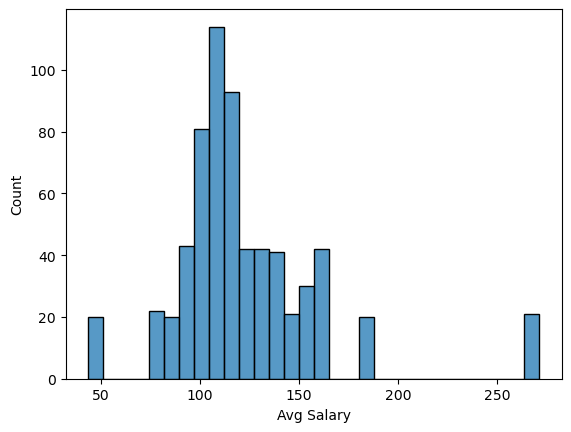

In [101]:
sns.histplot(new_df['Avg Salary'])

In [102]:
labels = ['Low','Medium','High','Very High']

def label_salary(salary):
    if salary < new_df['Avg Salary'].quantile(0.25):
        return 'Low'
    elif salary < new_df['Avg Salary'].quantile(0.5):
        return 'Medium'
    elif salary < new_df['Avg Salary'].quantile(0.75):
        return 'High'
    else:
        return 'Very High'
    

In [103]:
new_df['SalaryCategory'] = new_df['Avg Salary'].apply(label_salary)

In [104]:
new_df['SalaryCategory'].value_counts()

SalaryCategory
Very High    195
Medium       166
High         157
Low          154
Name: count, dtype: int64

In [105]:
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary,Revenue_clean,Revenue Min,Revenue Max,Revenue Avg,Company_year,RequiredSkills,Experience_Level,SalaryCategory
0,Sr Data Scientist,description\n\nthe senior data scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,NaN,"EmblemHealth, UnitedHealth Group, Aetna",154.0,NaN,NaN,NaN,NaN,32,[],Senior,Very High
1,Data Scientist,"secure our nation, ignite your future\n\njoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,1 to 2 billion,"Los Alamos National Laboratory, Battelle, SRI ...",154.0,1B - 2B,1.000000e+09,2.000000e+09,1.500000e+09,57,"[hadoop, SQL]",Mid-Level,Very High
2,Data Scientist,overview\n\n\nanalysis group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,100 to 500 million,"Booz Allen Hamilton, SAIC, LMI",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,44,"[R, Python]",Mid-Level,Very High
3,Data Scientist,job description:\n\ndo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,100 to 500 million,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,25,"[MATLAB, SQL, Python]",Mid-Level,Very High
4,Data Scientist,data scientist\naffinity solutions / marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",154.0,NaN,NaN,NaN,NaN,27,"[R, SQL, Python]",Mid-Level,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,summary\n\nwe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",3000,1989,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",136.0,NaN,NaN,NaN,NaN,36,"[hadoop, SQL, Python]",Mid-Level,Very High
668,Data Scientist,job description\nbecome a thought leader withi...,3.8,JKGT,"San Francisco, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1,[],Mid-Level,Very High
669,Data Scientist,join a thriving company that is changing the w...,3.8,AccessHope,"Irwindale, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1,"[Java, hadoop, SQL, Python, R, Scala]",Mid-Level,Very High
670,Data Scientist,100 remote opportunity as an ainlp data scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",25,-1,Company - Private,Advertising & Marketing,Business Services,1 to 5 million,"Commerce Signals, Cardlytics, Yodlee",136.0,1M - 5M,1.000000e+06,5.000000e+06,3.000000e+06,-1,"[Java, hadoop, Python, R, Scala]",Mid-Level,Very High


In [106]:
print(new_df['Job Description'][0])

description

the senior data scientist is responsible for defining, building, and improving statistical models to improve business processes and outcomes in one or more healthcare domains such as clinical, enrollment, claims, and finance. as part of the broader analytics team, data scientist will gather and analyze data to solve and address complex business problems and evaluate scenarios to make predictions on future outcomes and work with the business to communicate and support decision-making. this position requires strong analytical skills and experience in analytic methods including multivariate regressions, hierarchical linear models, regression trees, clustering methods and other complex statistical techniques.

duties & responsibilities:

• develops advanced statistical models to predict, quantify or forecast various operational and performance metrics in multiple healthcare domains
• investigates, recommends, and initiates acquisition of new data resources from internal and ex

In [107]:
Count = 0
for i in new_df['Job Description'].values:
    if 'qualifications' in i.lower():
        Count += 1
Count

306

In [108]:
# Data Analysis
# 1 - bachelor's degree
# 2 - master degree
# 3 - PhD
# 4 - Doctorate

In [109]:
def extract_education(info):
    education_levels = ['Bachelor', 'Master', 'PhD', 'Doctorate']
    level = []
    for i in education_levels:
        if i.lower() in info.lower():
            level.append(i)
    return list(set(level))

new_df['EducationLevel'] = new_df['Job Description'].apply(extract_education)

In [110]:
# years of experience from job description
def extract_experience(description):
    if pd.isna(description):
        return np.nan
    # Pattern matches '3 years', '3+ years', '3-5 years', '3 to 5 years', etc.
    patterns = [
        r'(\d+)\+?\s*(?:year|yr)s?',                      # 3 years, 5yrs, 3+ years
        r'(\d+)\s*[\-to]+\s*(\d+)\s*(?:year|yr)s?'        # 3-5 years, 3 to 5 years
    ]
    
    max_years = []
    for pattern in patterns:
        matches = re.findall(pattern, description, re.IGNORECASE)
        for match in matches:
            if isinstance(match, tuple):
                max_years.extend([int(m) for m in match])
            else:
                max_years.append(int(match))
    
    return max(max_years) if max_years else np.nan

In [111]:
new_df['YearsExperience'] =  new_df['Job Description'].apply(extract_experience)

In [112]:
new_df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary,Revenue_clean,Revenue Min,Revenue Max,Revenue Avg,Company_year,RequiredSkills,Experience_Level,SalaryCategory,EducationLevel,YearsExperience
0,Sr Data Scientist,description\n\nthe senior data scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",3000,1993,Nonprofit Organization,Insurance Carriers,Insurance,NaN,"EmblemHealth, UnitedHealth Group, Aetna",154.0,NaN,NaN,NaN,NaN,32,[],Senior,Very High,"[Bachelor, Master]",NaN
1,Data Scientist,"secure our nation, ignite your future\n\njoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",7500,1968,Company - Public,Research & Development,Business Services,1 to 2 billion,"Los Alamos National Laboratory, Battelle, SRI ...",154.0,1B - 2B,1.000000e+09,2.000000e+09,1.500000e+09,57,"[hadoop, SQL]",Mid-Level,Very High,[Bachelor],15.0
2,Data Scientist,overview\n\n\nanalysis group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",3000,1981,Private Practice / Firm,Consulting,Business Services,100 to 500 million,"Booz Allen Hamilton, SAIC, LMI",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,44,"[R, Python]",Mid-Level,Very High,[PhD],NaN
3,Data Scientist,job description:\n\ndo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",750,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,100 to 500 million,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154.0,100M - 500M,1.000000e+08,5.000000e+08,3.000000e+08,25,"[MATLAB, SQL, Python]",Mid-Level,Very High,[Bachelor],NaN
4,Data Scientist,data scientist\naffinity solutions / marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",125,1998,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",154.0,NaN,NaN,NaN,NaN,27,"[R, SQL, Python]",Mid-Level,Very High,[],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,summary\n\nwe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",3000,1989,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",136.0,NaN,NaN,NaN,NaN,36,"[hadoop, SQL, Python]",Mid-Level,Very High,[],2.0
668,Data Scientist,job description\nbecome a thought leader withi...,3.8,JKGT,"San Francisco, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1,[],Mid-Level,Very High,[],NaN
669,Data Scientist,join a thriving company that is changing the w...,3.8,AccessHope,"Irwindale, CA",-1,125,-1,-1,-1,-1,NaN,"AT&T, Verizon",136.0,NaN,NaN,NaN,NaN,-1,"[Java, hadoop, SQL, Python, R, Scala]",Mid-Level,Very High,[],3.0
670,Data Scientist,100 remote opportunity as an ainlp data scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",25,-1,Company - Private,Advertising & Marketing,Business Services,1 to 5 million,"Commerce Signals, Cardlytics, Yodlee",136.0,1M - 5M,1.000000e+06,5.000000e+06,3.000000e+06,-1,"[Java, hadoop, Python, R, Scala]",Mid-Level,Very High,"[PhD, Bachelor]",5.0


In [113]:
new_df.dtypes

Job Title             object
Job Description       object
Rating               float64
Company Name          object
Location              object
Headquarters          object
Size                   int64
Founded                int64
Type of ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
Avg Salary           float64
Revenue_clean         object
Revenue Min          float64
Revenue Max          float64
Revenue Avg          float64
Company_year           int64
RequiredSkills        object
Experience_Level      object
SalaryCategory        object
EducationLevel        object
YearsExperience      float64
dtype: object

In [114]:
# new_df.shape

In [115]:
new_df.replace(-1,np.nan,inplace=True)

In [116]:
new_df.isna().sum()

Job Title              0
Job Description        0
Rating                 0
Company Name           0
Location               0
Headquarters           0
Size                   0
Founded              118
Type of ownership      0
Industry               0
Sector                 0
Revenue              240
Competitors            0
Avg Salary            20
Revenue_clean        240
Revenue Min          240
Revenue Max          240
Revenue Avg          240
Company_year         118
RequiredSkills         0
Experience_Level       0
SalaryCategory         0
EducationLevel         0
YearsExperience      228
dtype: int64

In [117]:
columns_with_nan = new_df.columns[new_df.isna().any()]
columns_with_nan

Index(['Founded', 'Revenue', 'Avg Salary', 'Revenue_clean', 'Revenue Min',
       'Revenue Max', 'Revenue Avg', 'Company_year', 'YearsExperience'],
      dtype='object')

In [118]:
# new_df.columns[new_df.isna().sum() > 0]

In [119]:
import seaborn as sns
print(sns.__version__)


0.13.2


<Axes: xlabel='Rating', ylabel='Count'>

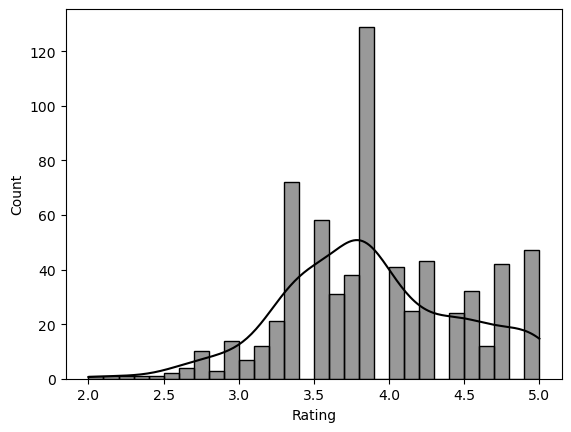

In [120]:
sns.histplot(x='Rating',data=new_df,color='k',kde=True,alpha=0.4,bins=30)

In [121]:
new_df['Rating'].skew()

0.05038228642609314

In [122]:
new_df['Rating'].mean()

3.8757440476190474

In [123]:
new_df['Rating'].median()

3.8

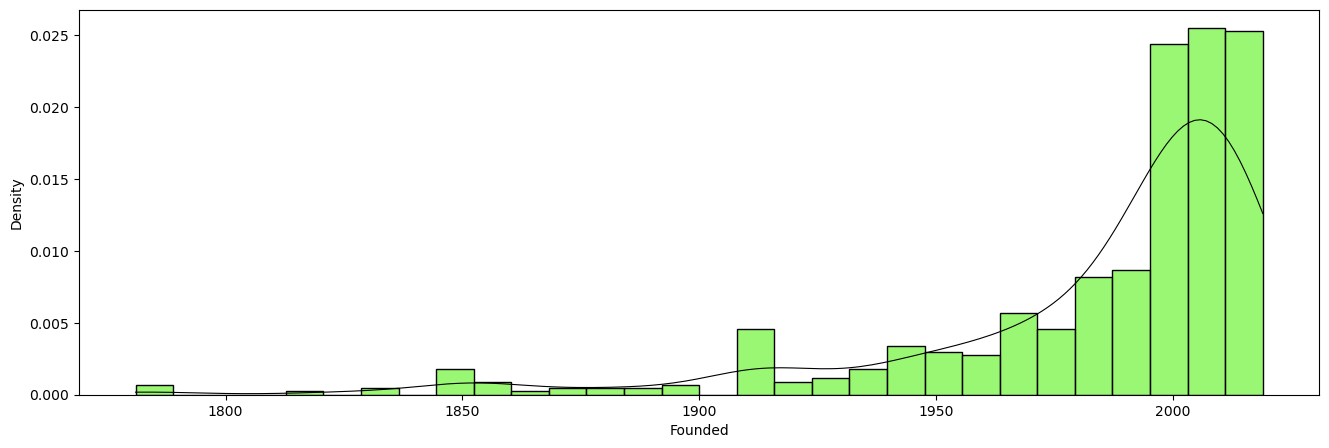

In [124]:
plt.figure(figsize=(16,5))
sns.histplot(new_df['Founded'], bins=30,color='#77f544', edgecolor='black',stat='density' )

# KDE (separately,  black)
sns.kdeplot(
    new_df['Founded'],
    color='black',
    linewidth=0.8,
    clip=(new_df['Founded'].min(), new_df['Founded'].max())

)

plt.show()

In [125]:
new_df['Founded'].isna().sum()

118

In [126]:
new_df['Founded'].median()

1999.0

In [127]:
# new_df['Founded'].min()

In [128]:
new_df['Founded'].fillna(new_df['Founded'].median(),inplace=True)

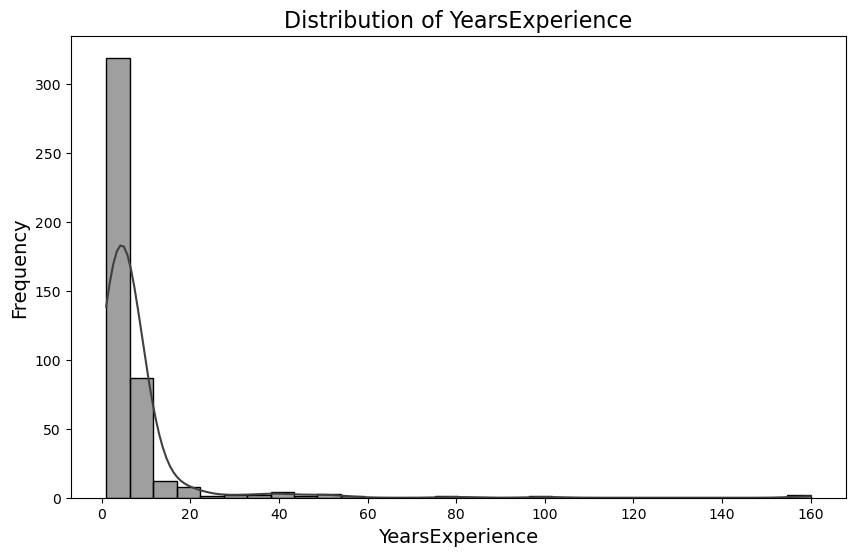

In [129]:
# See the YearsExperience column histplot, Is it skewed
plt.figure(figsize=(10, 6))
sns.histplot(x='YearsExperience', data=new_df, bins=30, color='#3f413e', edgecolor='black',kde=True)


# Add titles and labels
plt.title('Distribution of YearsExperience', fontsize=16)
plt.xlabel('YearsExperience', fontsize=14)
plt.ylabel('Frequency', fontsize=14)


# Show the plot
plt.show()

In [130]:
new_df.describe()

,Rating,Size,Founded,Avg Salary,Revenue Min,Revenue Max,Revenue Avg,Company_year,YearsExperience
count,672.000000,672.000000,672.000000,652.000000,4.320000e+02,4.320000e+02,4.320000e+02,554.000000,444.000000
mean,3.875744,1326.674107,1986.720238,121.782209,1.893197e+09,2.498227e+09,2.195712e+09,40.895307,7.452703
std,0.588001,2198.194792,37.339531,38.672997,3.464578e+09,3.641650e+09,3.512952e+09,40.653609,13.746168
min,2.000000,25.000000,1781.000000,43.500000,0.000000e+00,1.000000e+06,5.000000e+05,6.000000,1.000000
25%,3.500000,125.000000,1983.000000,103.000000,2.500000e+07,5.000000e+07,3.750000e+07,15.000000,3.000000
50%,3.800000,125.000000,1999.000000,114.000000,1.000000e+08,5.000000e+08,3.000000e+08,26.000000,5.000000
75%,4.300000,750.000000,2009.000000,136.000000,2.000000e+09,5.000000e+09,3.500000e+09,51.000000,7.000000
max,5.000000,7500.000000,2019.000000,271.500000,1.000000e+10,1.000000e+10,1.000000e+10,244.000000,160.000000


In [131]:
from sklearn.impute import KNNImputer


knn_imputer = KNNImputer(n_neighbors=5)

new_df[['YearsExperience', 'Revenue Avg']] = knn_imputer.fit_transform(new_df[['YearsExperience', 'Revenue Avg']])

In [132]:
new_df.describe()

,Rating,Size,Founded,Avg Salary,Revenue Min,Revenue Max,Revenue Avg,Company_year,YearsExperience
count,672.000000,672.000000,672.000000,652.000000,4.320000e+02,4.320000e+02,6.720000e+02,554.000000,672.000000
mean,3.875744,1326.674107,1986.720238,121.782209,1.893197e+09,2.498227e+09,2.590227e+09,40.895307,7.699147
std,0.588001,2198.194792,37.339531,38.672997,3.464578e+09,3.641650e+09,3.082828e+09,40.653609,11.281594
min,2.000000,25.000000,1781.000000,43.500000,0.000000e+00,1.000000e+06,5.000000e+05,6.000000,1.000000
25%,3.500000,125.000000,1983.000000,103.000000,2.500000e+07,5.000000e+07,3.000000e+08,15.000000,3.000000
50%,3.800000,125.000000,1999.000000,114.000000,1.000000e+08,5.000000e+08,1.625000e+09,26.000000,5.600000
75%,4.300000,750.000000,2009.000000,136.000000,2.000000e+09,5.000000e+09,3.500000e+09,51.000000,8.000000
max,5.000000,7500.000000,2019.000000,271.500000,1.000000e+10,1.000000e+10,1.000000e+10,244.000000,160.000000


In [137]:
new_df.sample()

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Avg Salary,Revenue_clean,Revenue Min,Revenue Max,Revenue Avg,Company_year,RequiredSkills,Experience_Level,SalaryCategory,EducationLevel,YearsExperience
356,Data Analyst,nolij consulting llc is a certified women-owne...,3.9,Nolij Consulting,"Falls Church, VA","Vienna, VA",125,2012.0,Company - Public,Consulting,Business Services,1 to 5 million,"Booz Allen Hamilton, SAIC, LMI",134.0,1M - 5M,1000000.0,5000000.0,3000000.0,13.0,"[R, SQL, Python]",Mid-Level,High,[Bachelor],4.6


In [144]:
new_df['Company_year'].fillna(2025 - new_df['Founded'],inplace=True)

In [153]:
new_df['Type of ownership'].replace('-1',new_df['Type of ownership'].mode()[0],inplace=True)

In [157]:
new_df['Sector'].replace('-1',new_df['Sector'].mode()[0],inplace=True)

In [160]:
new_df.loc[new_df['Industry'] == '-1', 'Industry'] = np.nan

In [161]:
# new_df['Industry'].mode()[0]

'Biotech & Pharmaceuticals'

In [162]:
new_df['Industry'].fillna(new_df['Industry'].mode()[0],inplace=True)

In [164]:
new_df.isnull().sum()

Job Title              0
Job Description        0
Rating                 0
Company Name           0
Location               0
Headquarters           0
Size                   0
Founded                0
Type of ownership      0
Industry               0
Sector                 0
Revenue              240
Competitors            0
Avg Salary            20
Revenue_clean        240
Revenue Min          240
Revenue Max          240
Revenue Avg            0
Company_year           0
RequiredSkills         0
Experience_Level       0
SalaryCategory         0
EducationLevel         0
YearsExperience        0
dtype: int64

In [167]:
new_df.to_csv("datascience.csv",index=False)

### EDA Part

### Univarte Analysis

#### 1. **What’s the distribution of `Rating`?**
   – Plot a histogram and boxplot; compute mean, median, mode, skewness and kurtosis.

#### 2. **Which are the top 10 most common `Job Title`s?**
   – Tabulate frequencies and visualize with a bar chart.

#### 3. **How many listings does each `Location` have?**
   – Generate a frequency table; consider mapping these counts geographically or via a horizontal bar chart.

#### 4. **What’s the length distribution of `Job Description`s?**
   – Compute character/word counts for each description; display a density plot or boxplot to see typical job‐description size.

#### 5. **Which `Company Name`s appear most often?**
   – List the top 10 companies by posting count, then visualize as a bar chart (or Pareto chart) to see where your data is concentrated.